In [4]:
#Step 1 :Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [8]:
#Step 2:Load Dataset
df=pd.read_csv(f"C:\\Users\\GAJAWADAYASHWANTH\\Downloads\\archive (3)\\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

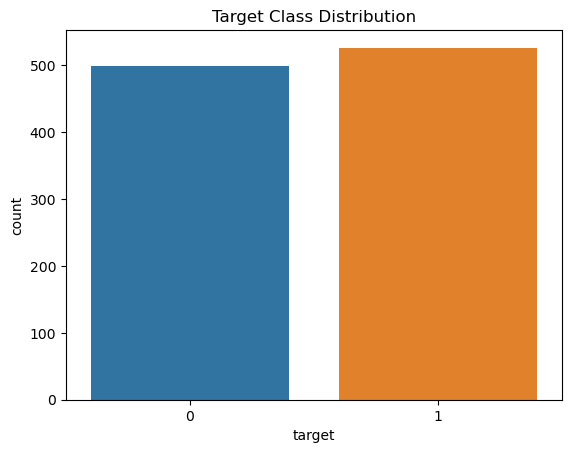

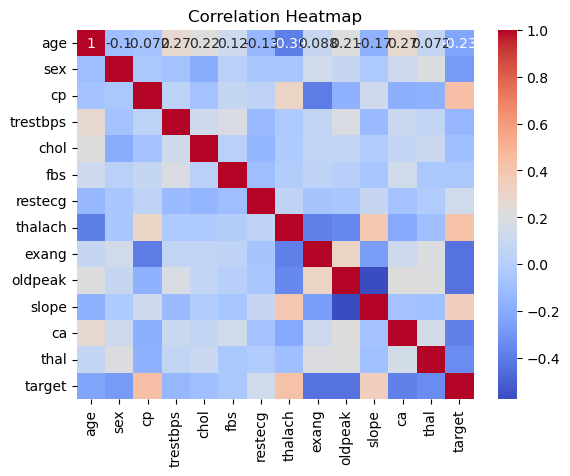

In [10]:
#Step 3:Exploratory Data Analysis
print(df.info())
print(df.describe())
print(df['target'].value_counts())

sns.countplot(x='target',data=df)
plt.title("Target Class Distribution")
plt.show()

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
#Step 4:Data PreProcessing
X=df.drop('target',axis=1)
y=df['target']

#Standardization
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,stratify=y,random_state=42)

In [13]:
#Step-5:Train a Decisison tree
dt=DecisionTreeClassifier(max_depth=4,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

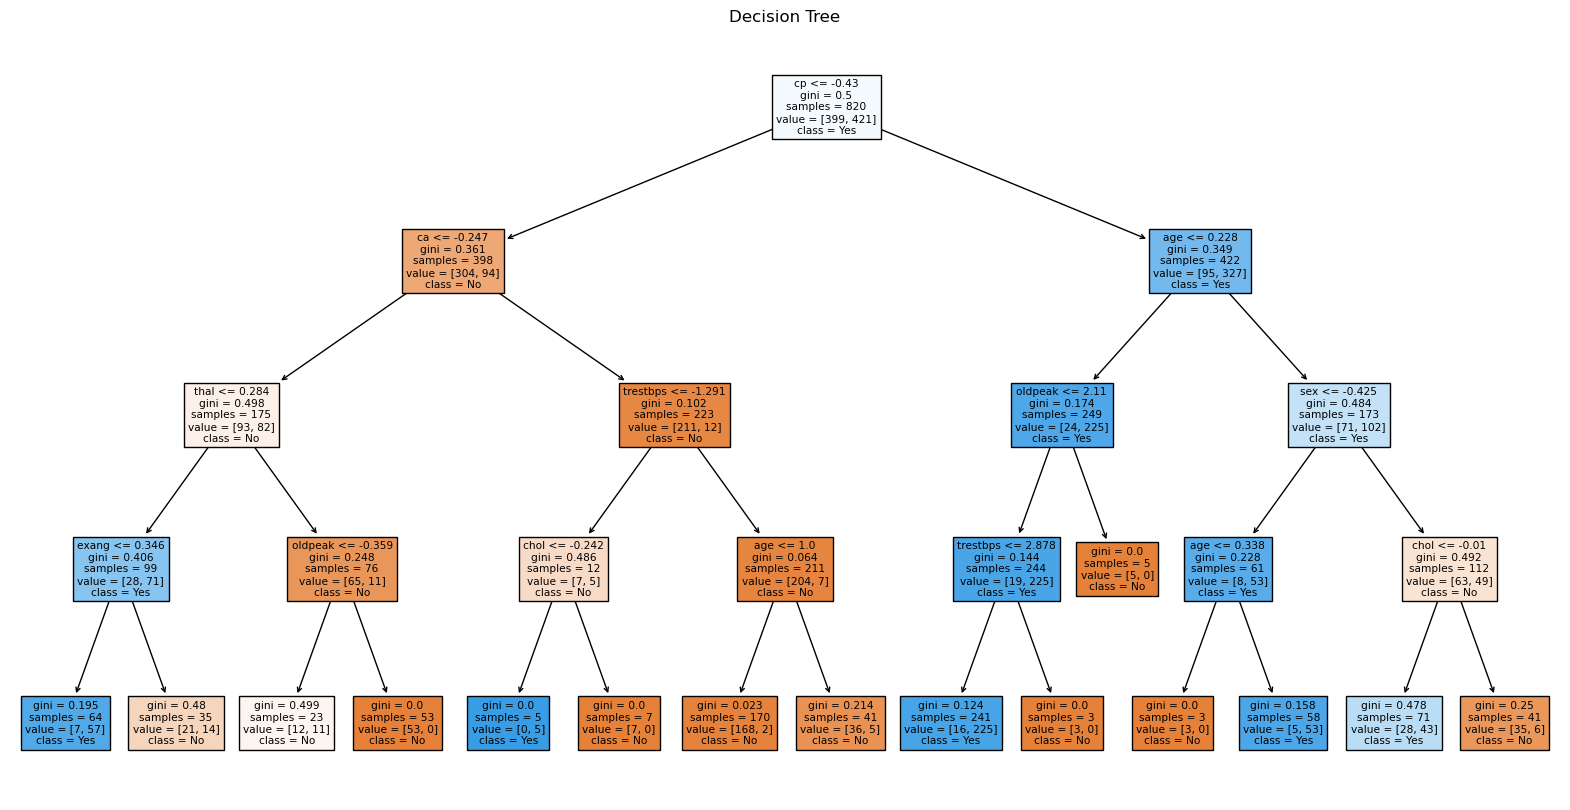

In [17]:
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,feature_names=df.columns[:-1],class_names=["No","Yes"])
plt.title("Decision Tree")
plt.show()

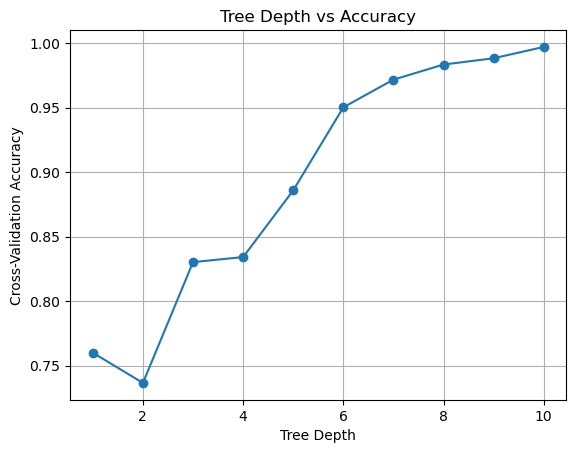

In [21]:
#Cross validation to check overfittin
depths=range(1,11)
cv_scores=[np.mean(cross_val_score(DecisionTreeClassifier(max_depth=d),x_scaled,y,cv=5)) for d in depths]

plt.plot(depths,cv_scores,marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Tree Depth vs Accuracy")
plt.grid(True)
plt.show()


In [22]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [23]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[ 88  12]
 [  3 102]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       100
           1       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205

Accuracy Score: 0.926829268292683


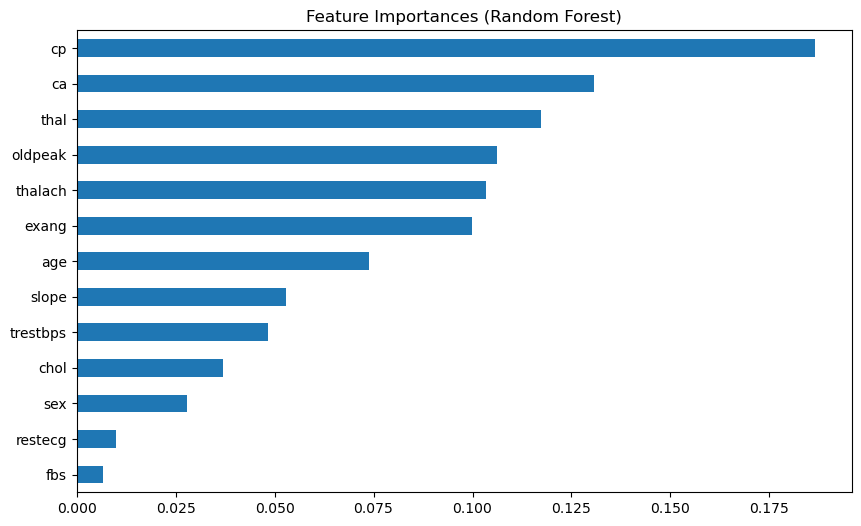

In [24]:
importances = pd.Series(rf.feature_importances_, index=df.columns[:-1])
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importances (Random Forest)")
plt.show()
